In [32]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# GENERAL PLOT OPTIONS
# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'

from scipy.interpolate import interp1d
from scipy.integrate import quad

In [1]:
import numpy as np

nlens = 10
nsrcs = 5
ntheta=20
tmin = 1
tmax = 500

dvF_file = '/project/chihway/junzhou/firecrown/lsst_real/output_factory/data_vector/firecrown_theory.txt'
dvC_file = '/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/chains/lsst_takahashi_evaluate/lsst_takahashi.modelvector'
cov_file = '/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/data/cov_lsst'
mask_file = '/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/data/lsst_Y3.mask'

dvF = np.loadtxt(dvF_file)
dvC = np.loadtxt(dvC_file)[:,1]
mask = np.loadtxt(mask_file)[:,1]

cov_raw = np.loadtxt(cov_file)
cov = np.zeros((len(mask),len(mask)))
for idx in range(len(cov_raw)):
    ii = int(cov_raw[idx,0])
    jj = int(cov_raw[idx,1])
    element = cov_raw[idx,8] + cov_raw[idx,9]
    cov[ii,jj] = element
    cov[jj,ii] = element
    
#thetas used in COCOA
vmin = tmin
vmax = tmax
N = ntheta
logdt = (np.log(vmax) - np.log(vmin))/N
fac = (2./3.)
thetas = []
for i in range(int(N)):
    thetamin = np.exp(np.log(vmin) + (i + 0.)*logdt)
    thetamax = np.exp(np.log(vmin) + (i + 1.)*logdt)
    thetas.append(fac * (thetamax**3 - thetamin**3) / (thetamax**2 - thetamin**2))
thetas = np.array(thetas)

In [2]:
#chi2 after mask
from scipy.linalg import pinv

delta = dvF - dvC
masked_delta = delta[mask.astype(bool)]
masked_cov = cov[mask.astype(bool), :][:, mask.astype(bool)]
chi2 = masked_delta@pinv(masked_cov)@masked_delta
print('total chi2 after mask:', chi2)

total chi2 after mask: 213.1548717194774


In [3]:
import matplotlib.pyplot as plt
def plot_snapshot(l,r,probe,combo):
    fig,axs = plt.subplots(2,1, figsize=(12,8))
    plt.subplots_adjust(hspace=0.05)
    axs[0].plot(thetas, dvF[l:r], label='Firecrown')
    axs[0].plot(thetas, dvC[l:r], label='COCOA')
    axs[0].set_yscale('log')
    axs[0].set_xscale('log')
    axs[0].set_title(probe+' '+combo)
    axs[0].tick_params(axis='x', labelbottom=False)
    axs[0].legend()
    
    delta = (dvF[l:r] - dvC[l:r])/dvC[l:r]
    axs[1].plot(thetas, delta, label='(F-C)/C',marker='o')
    axs[1].set_xscale('log')
    cov_seg = cov[l:r,:][:,l:r]
    sigmas = np.array([np.sqrt(cov_seg[i,i]) for i in range(len(cov_seg))])
    axs[1].fill_between(thetas,-sigmas/dvC[l:r],+sigmas/dvC[l:r],step='mid',facecolor='lightgray',alpha=0.5,label=r'$\pm\sigma/C$',)
    axs[1].axhline(xmin=0,xmax=1,y=0.0,color='k',linestyle='--')
    axs[1].set_ylim(-0.1, 0.1)
    axs[1].set_xlabel(r'$\theta(\mathrm{arcmin})$')
    axs[1].legend()
    
    plt.show()

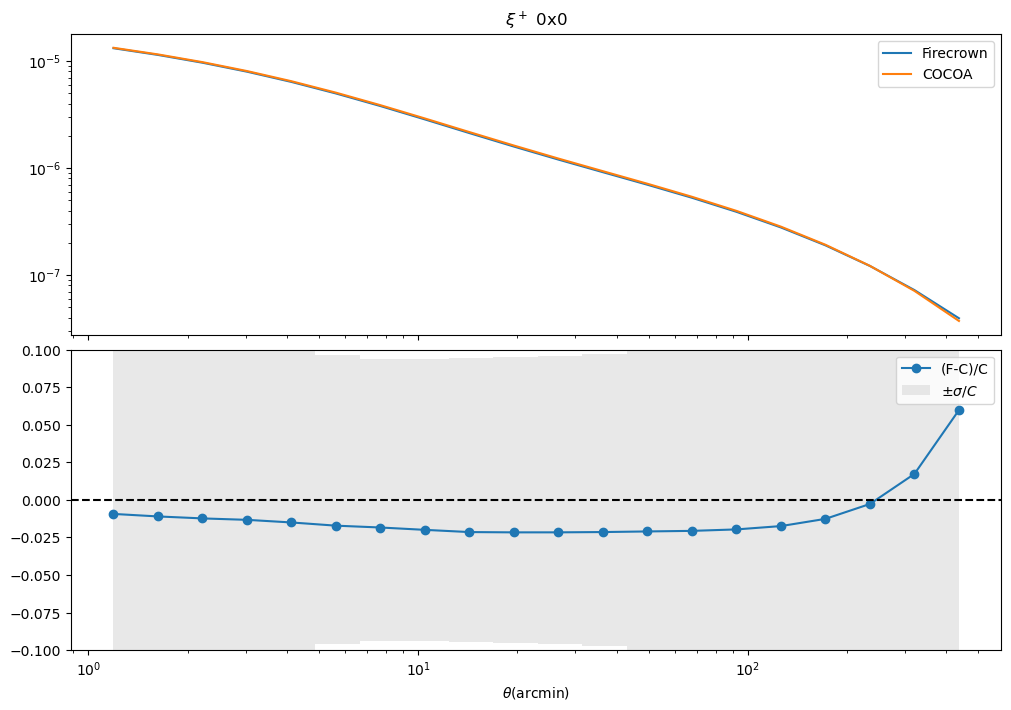

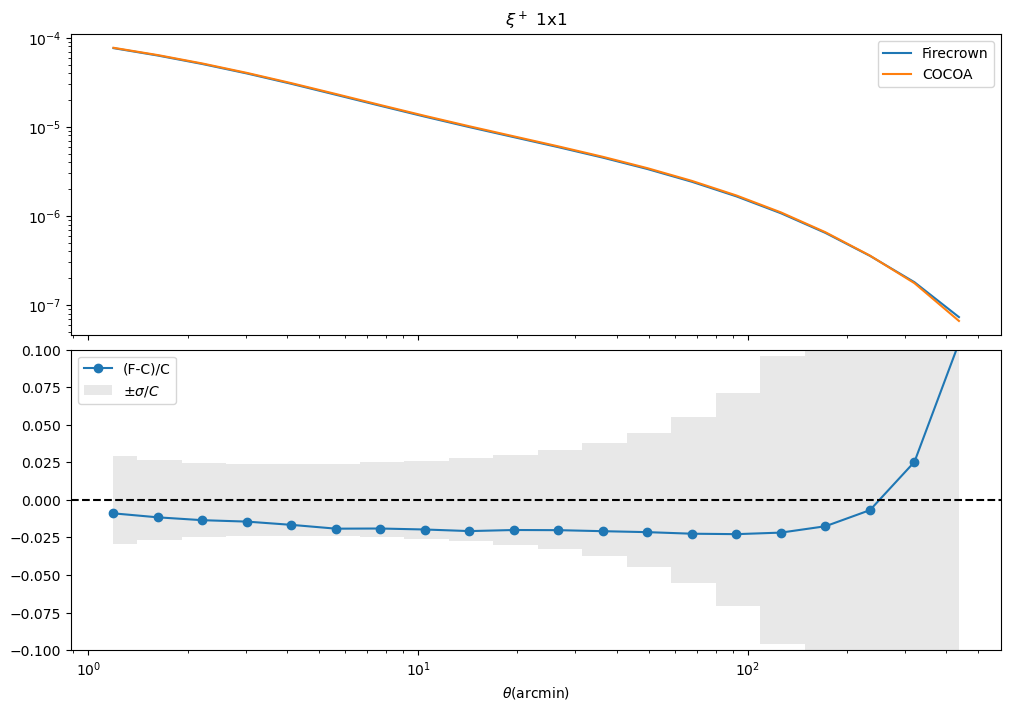

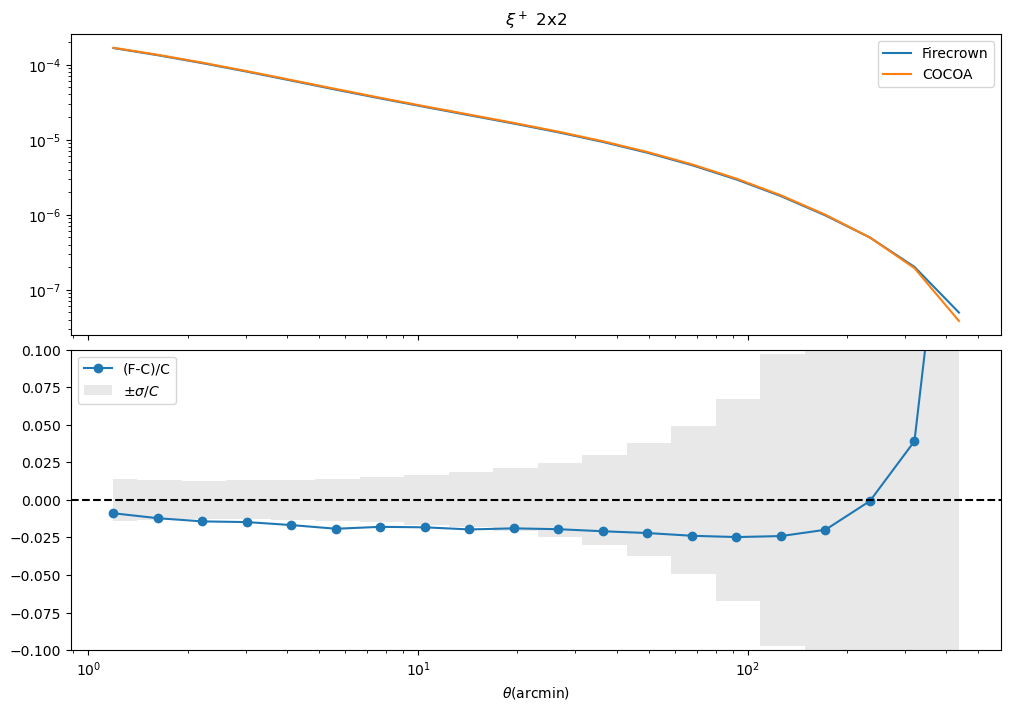

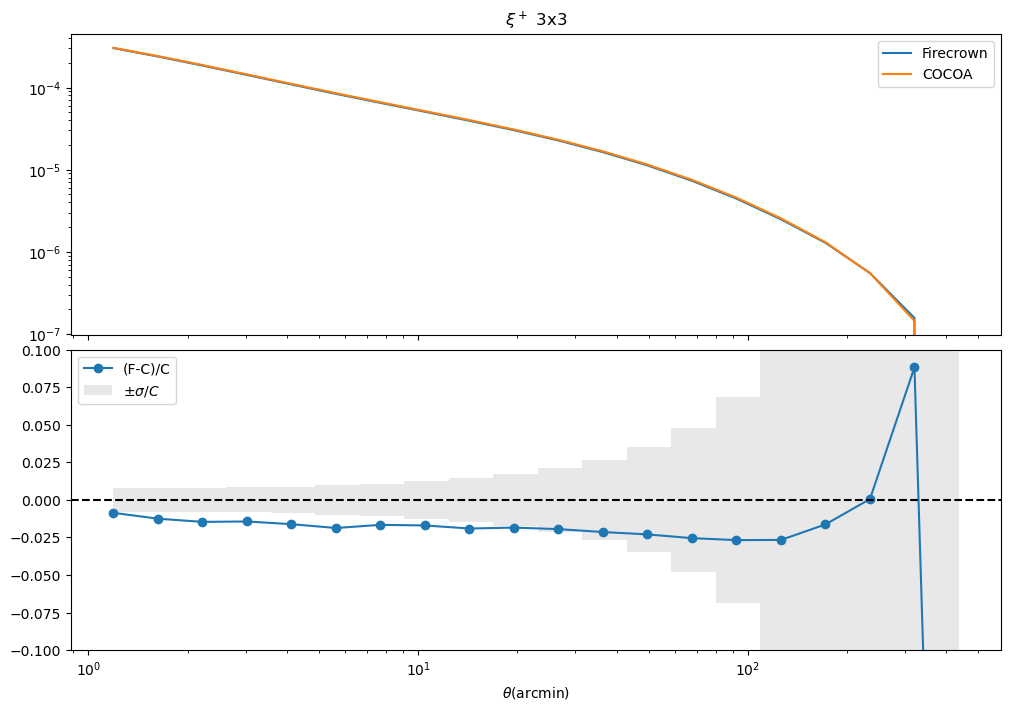

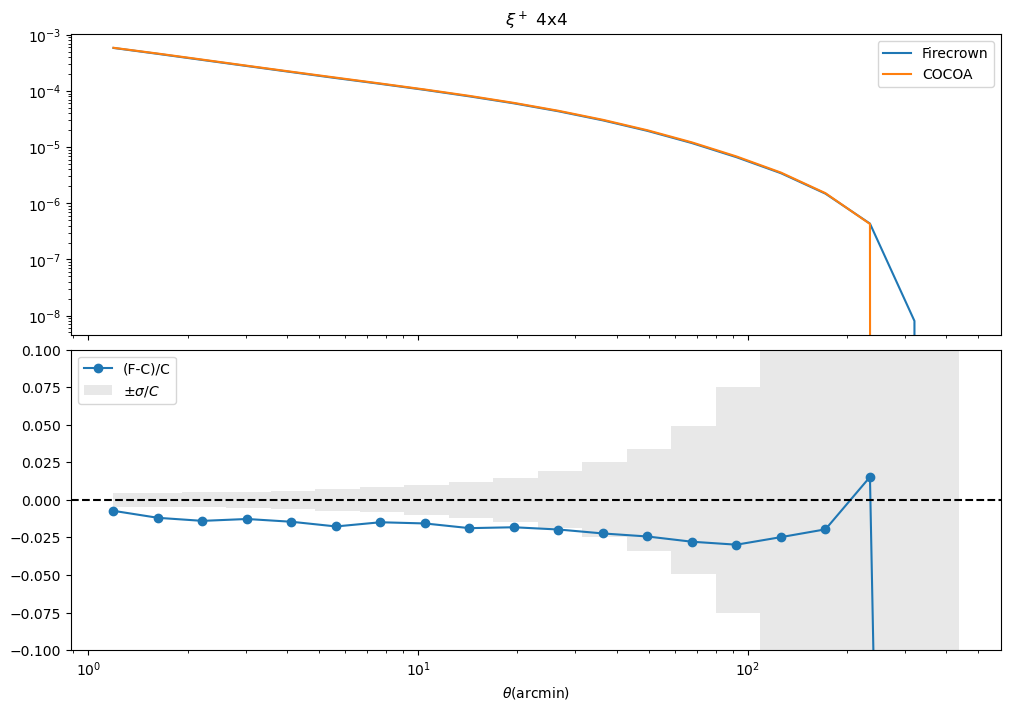

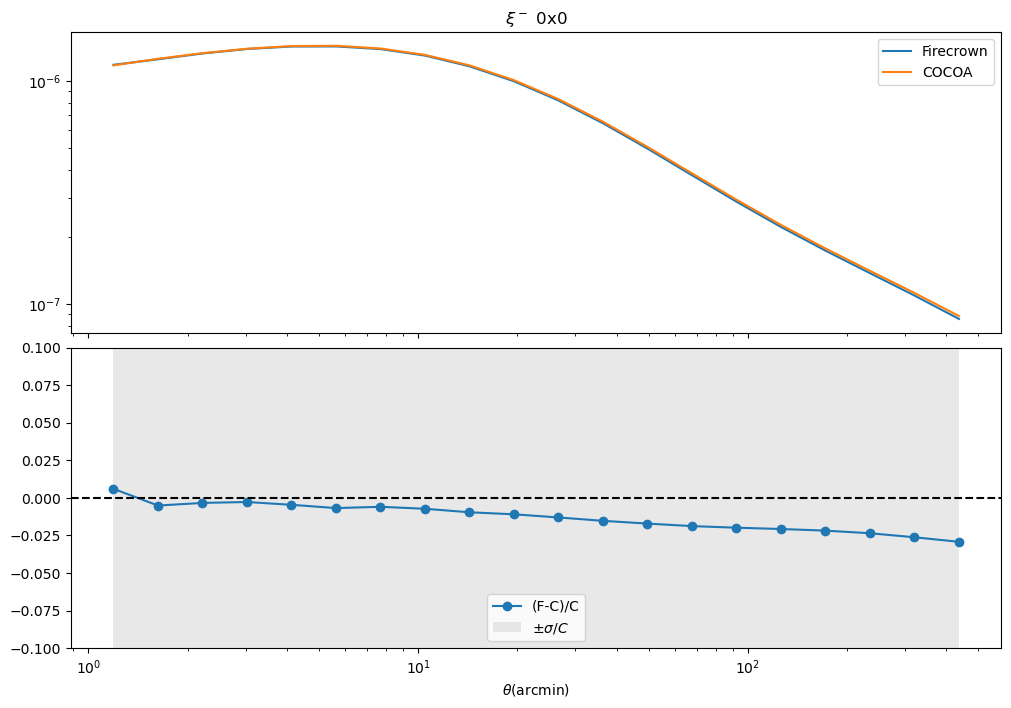

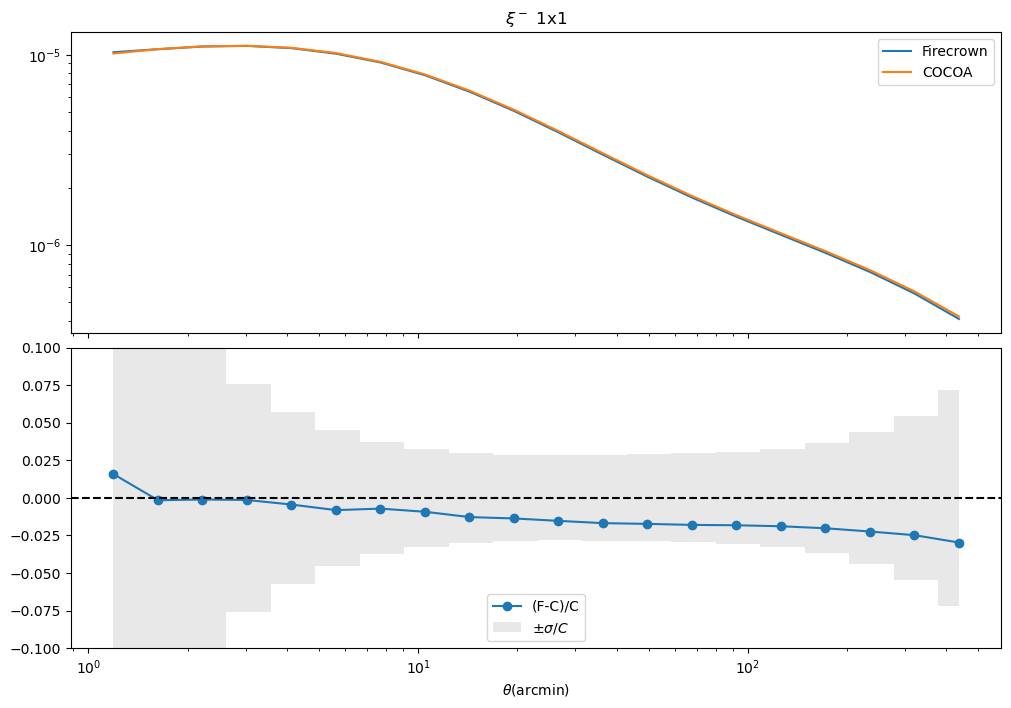

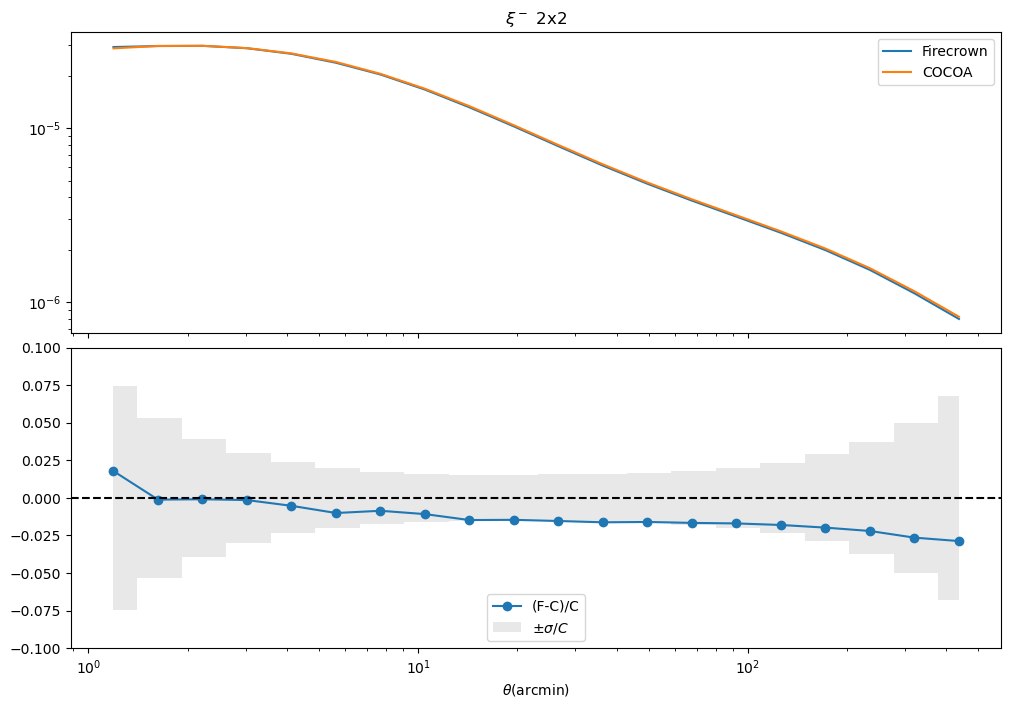

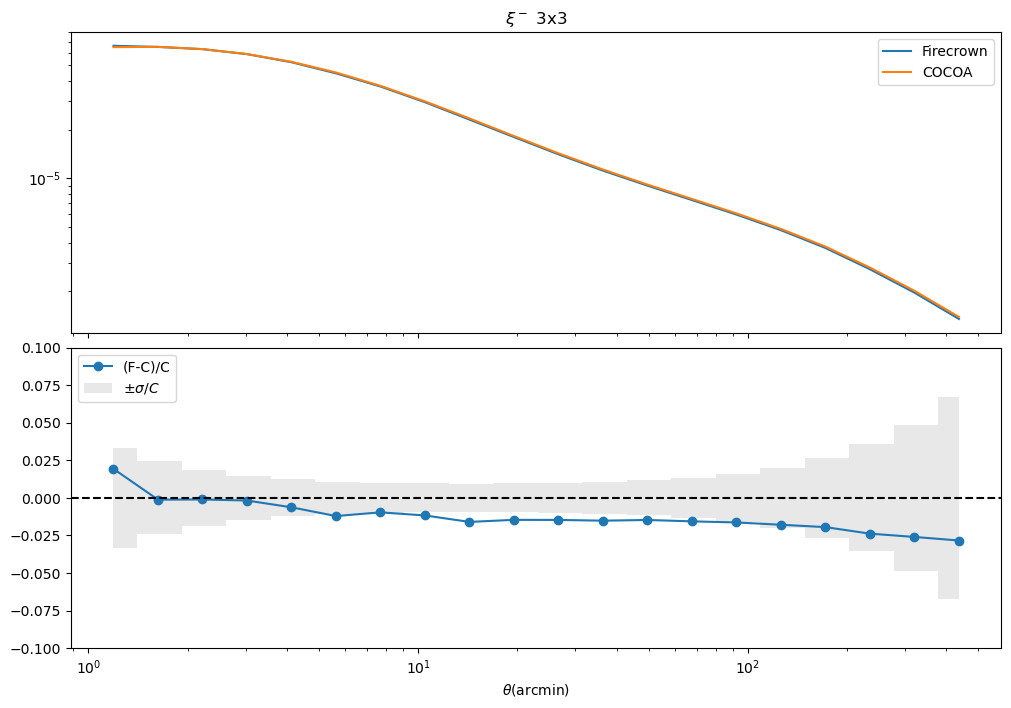

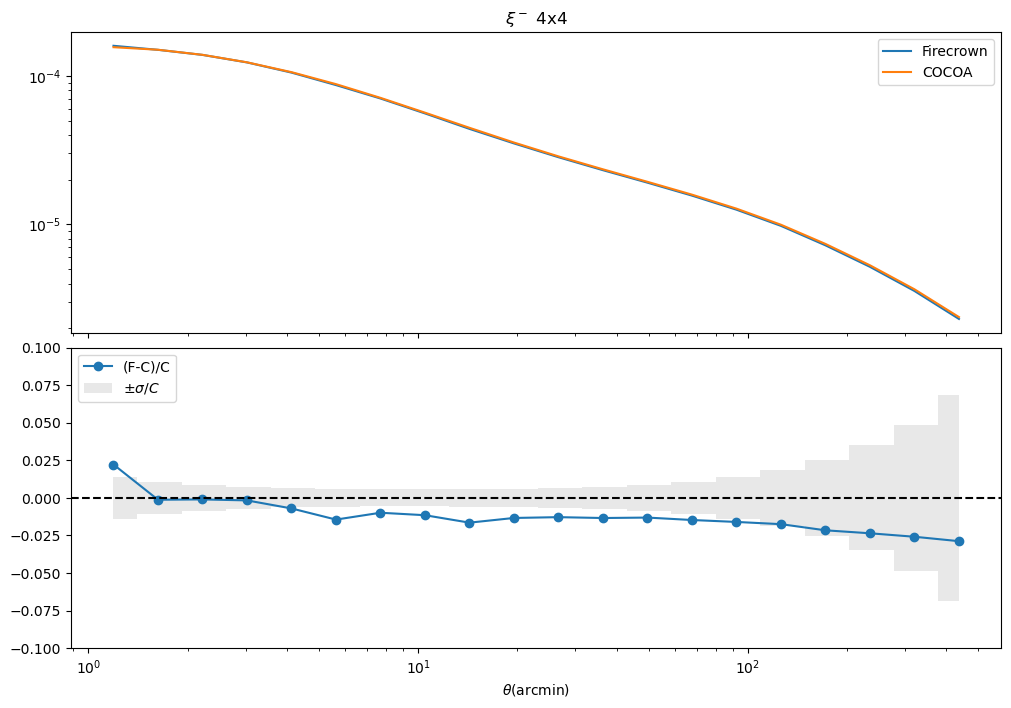

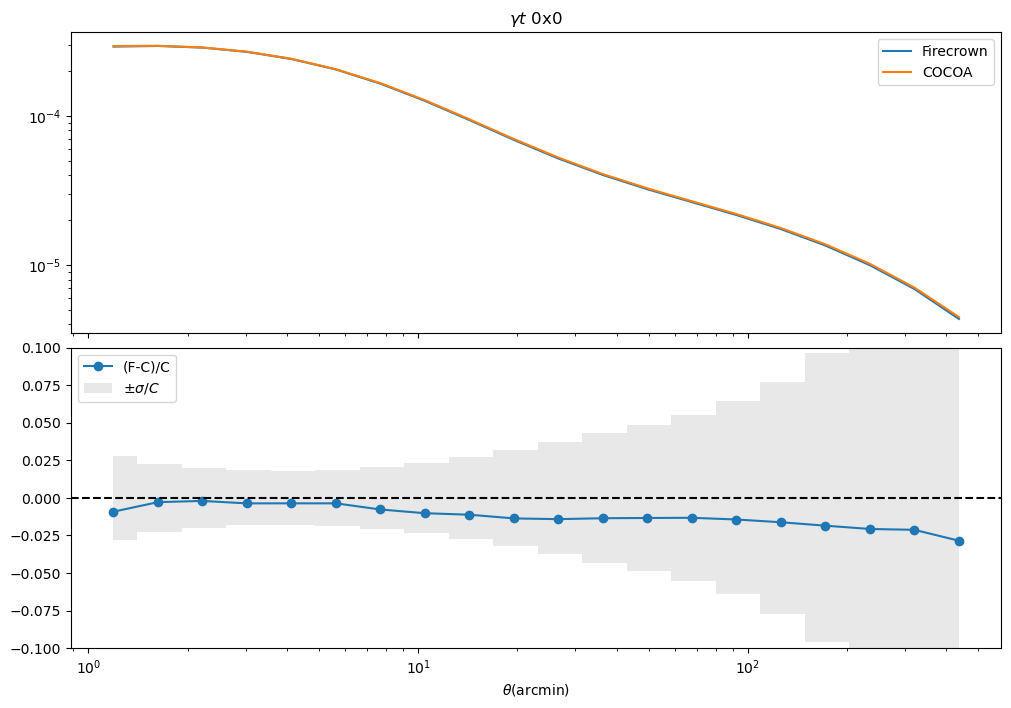

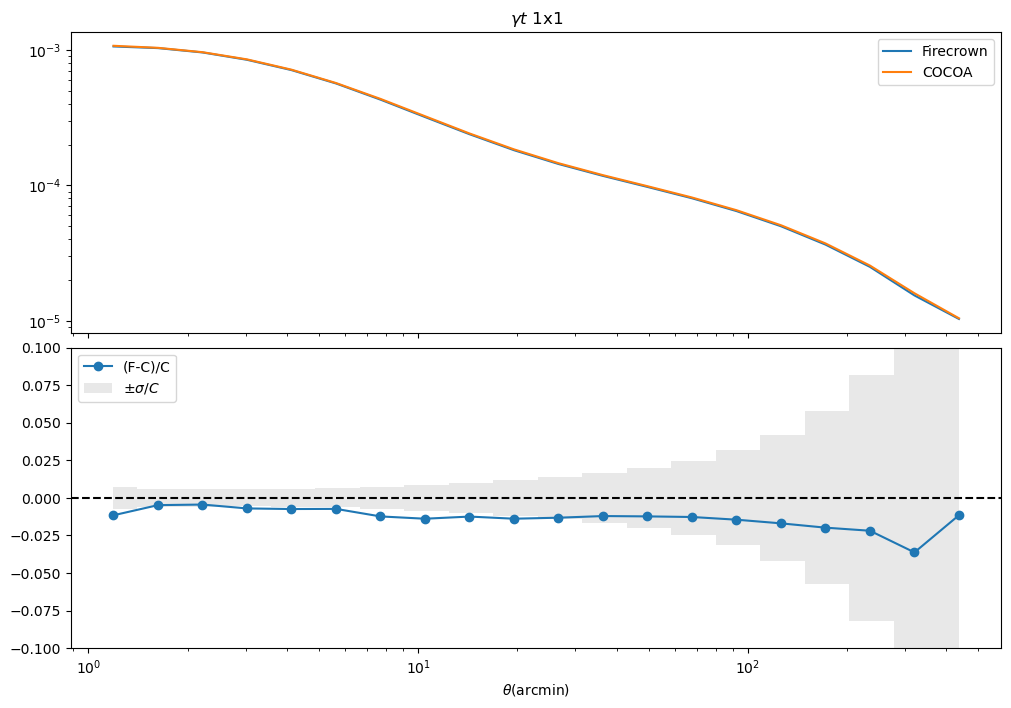

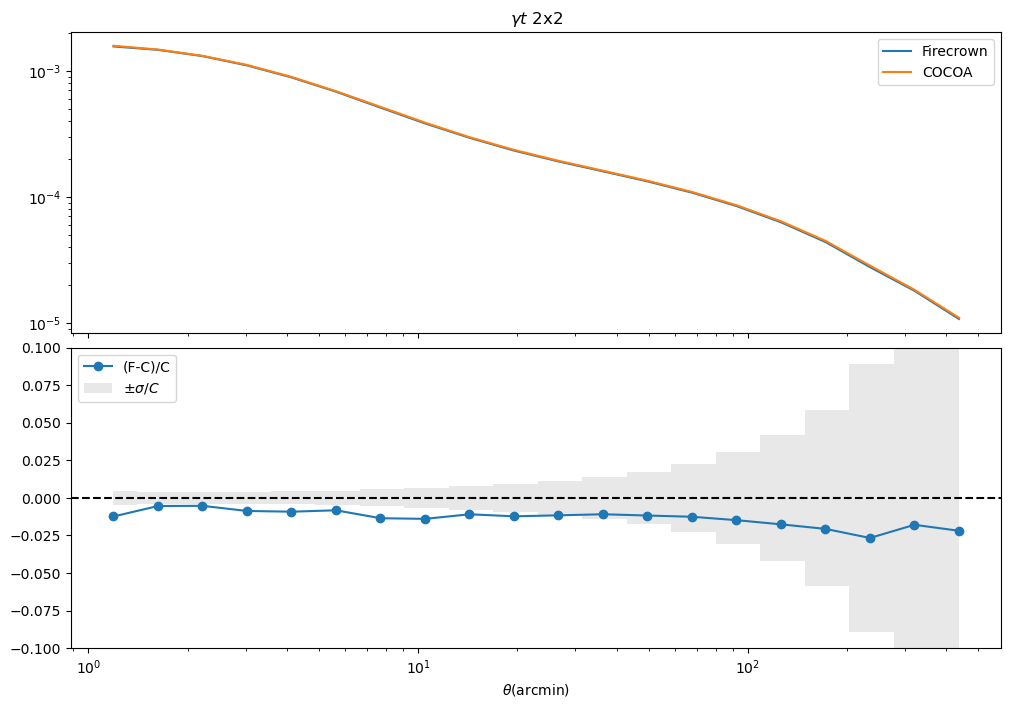

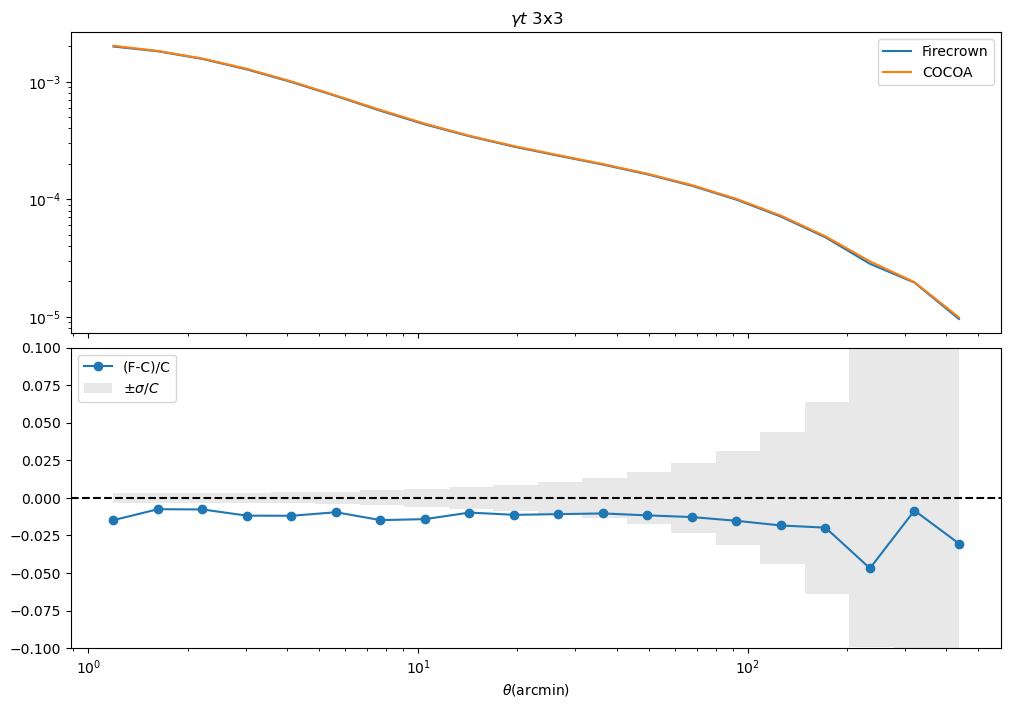

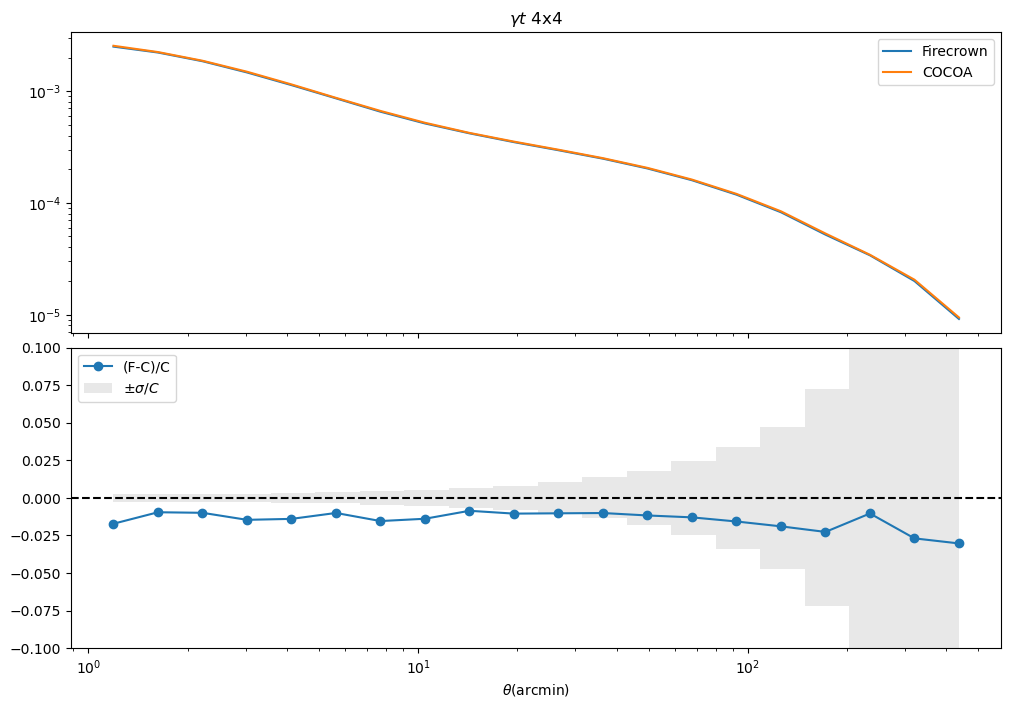

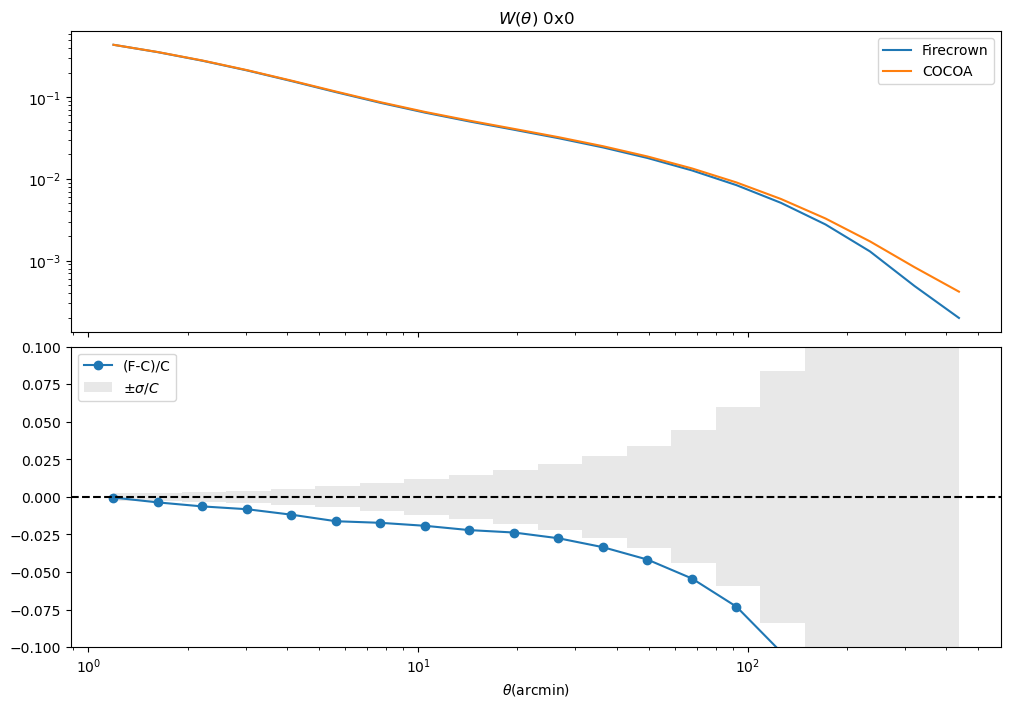

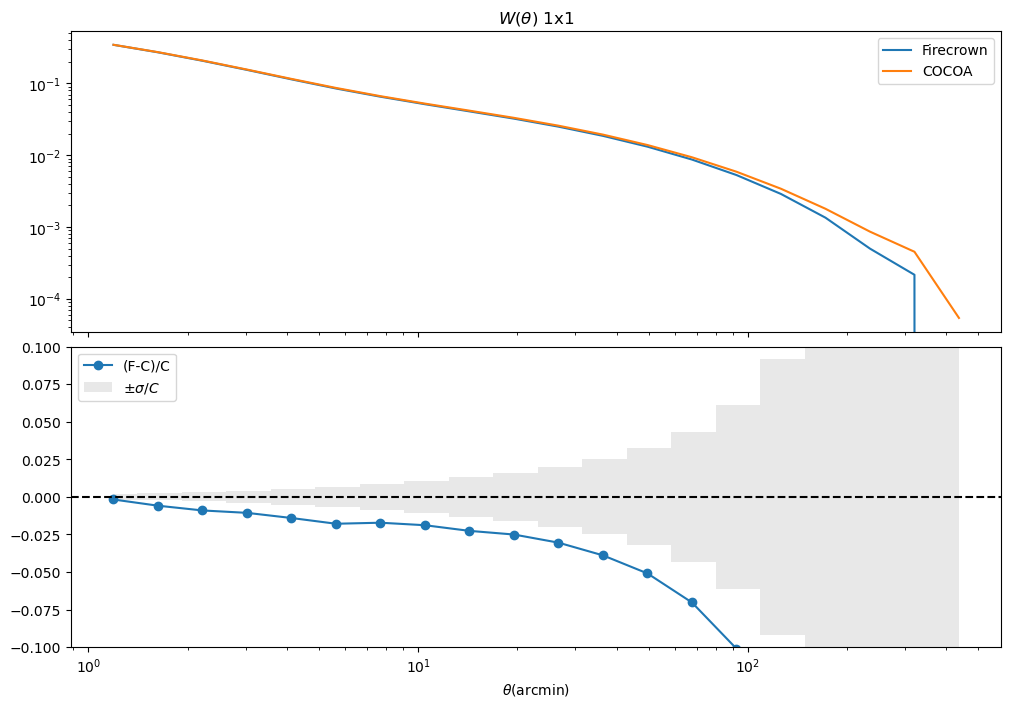

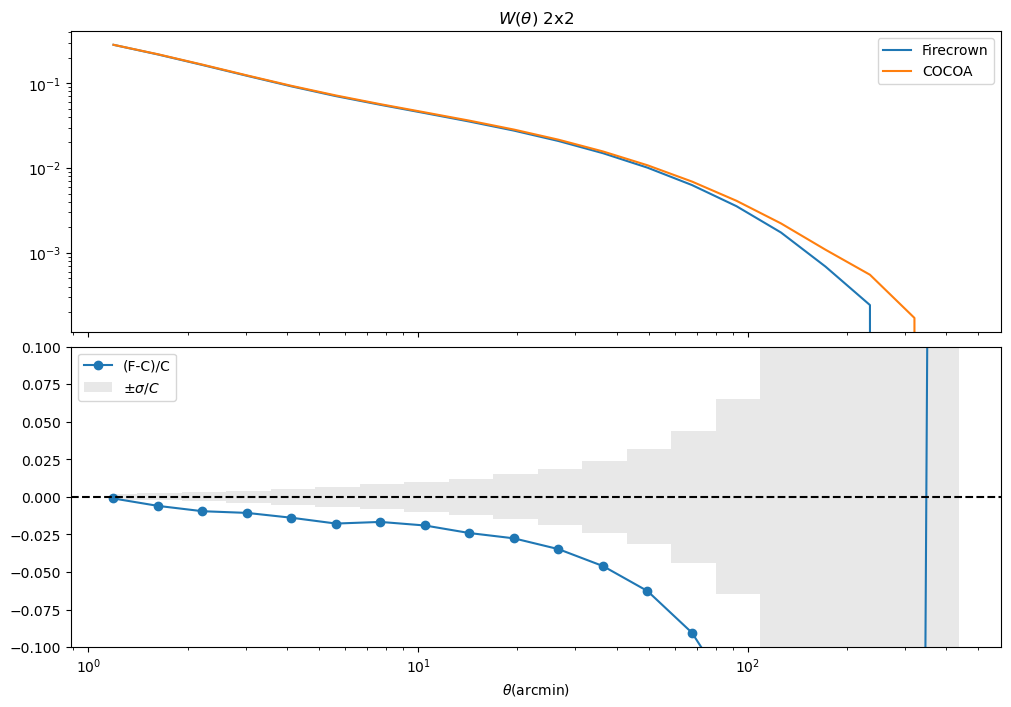

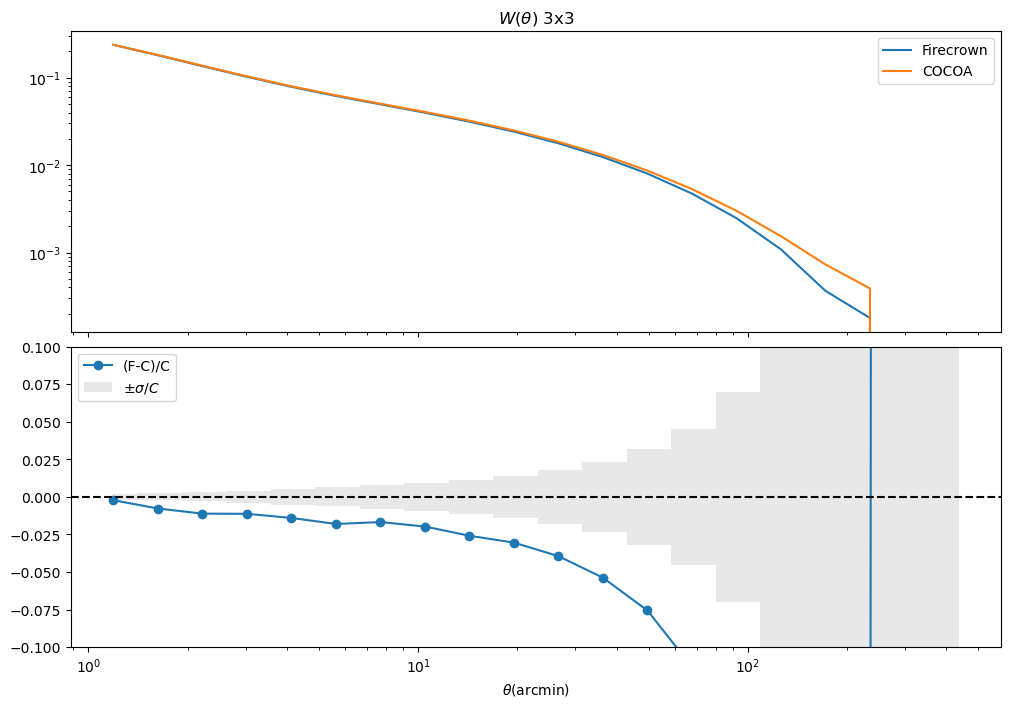

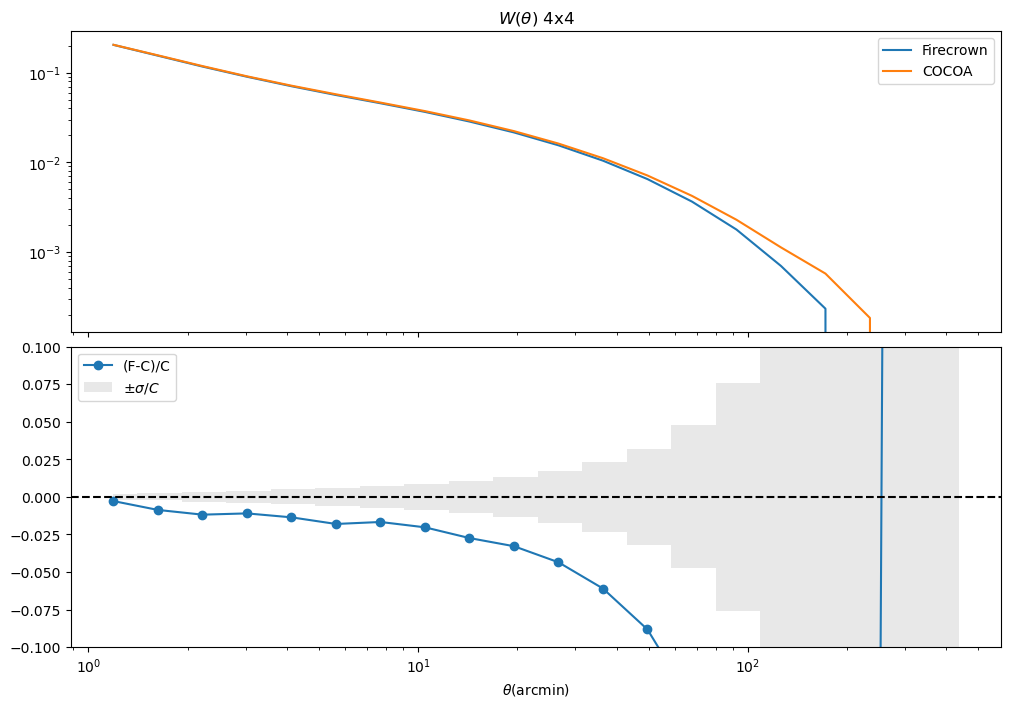

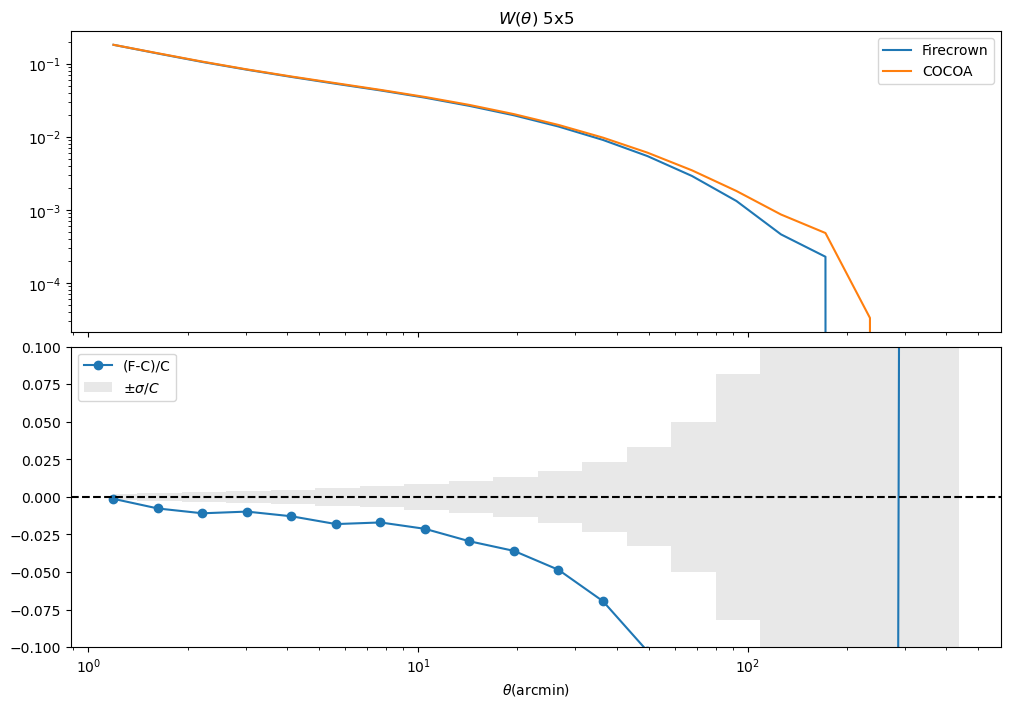

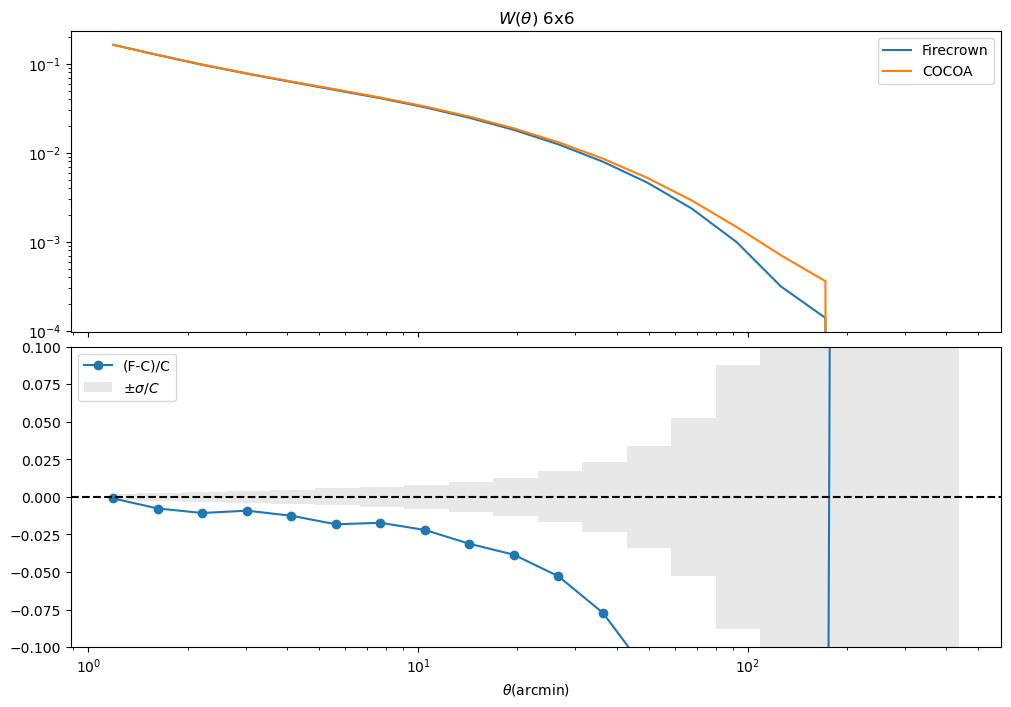

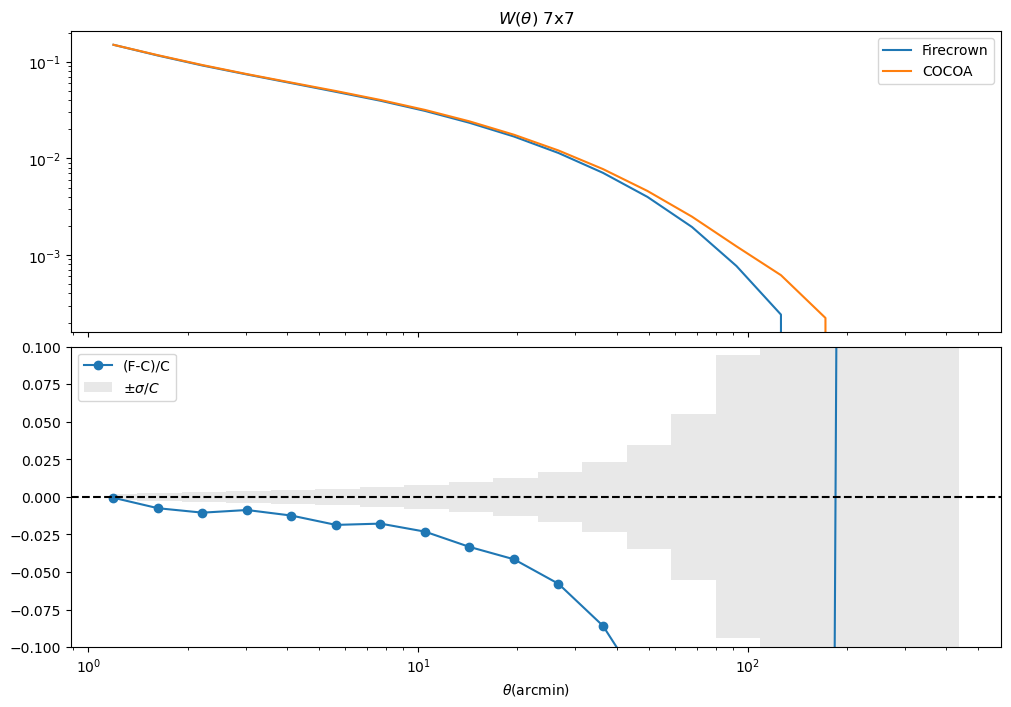

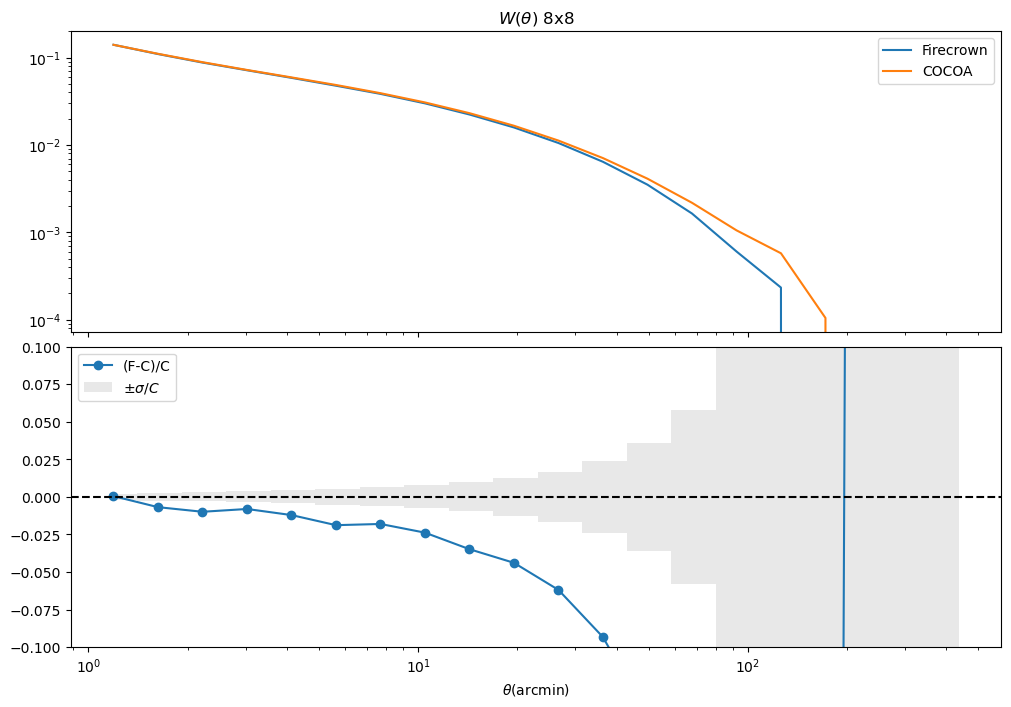

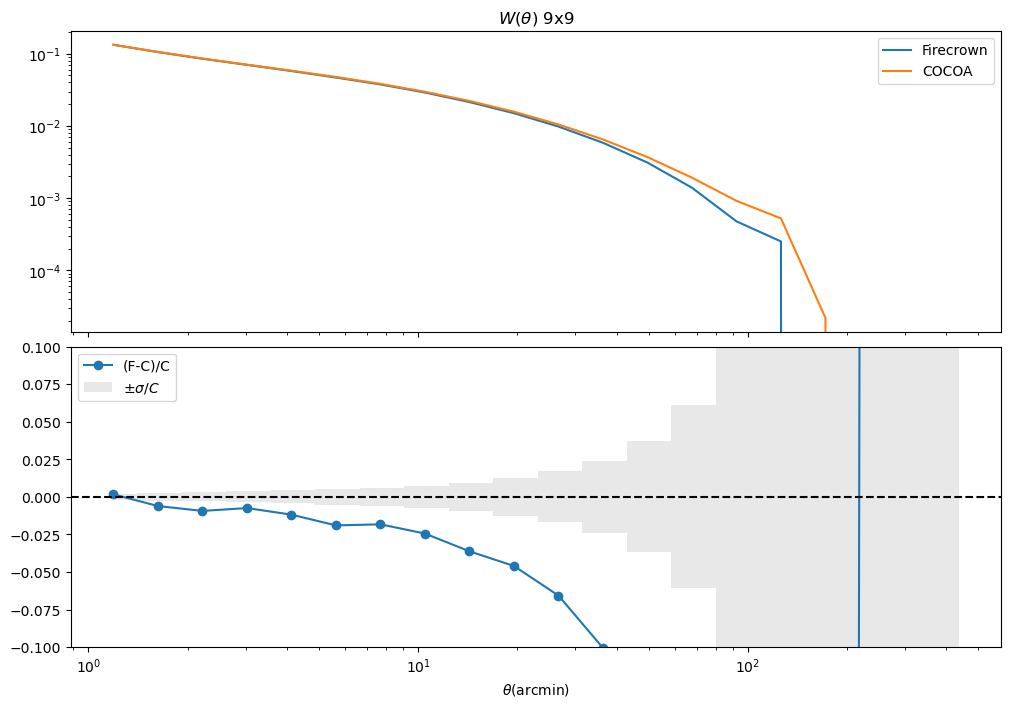

In [4]:
#snapshot
cnt = 0
for i in range(nsrcs):
    for j in range(i, nsrcs):
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        if i==j:
            plot_snapshot(l,r, probe=r'$\xi^+$', combo=f'{i}x{j}')
        cnt+=1
for i in range(nsrcs):
    for j in range(i, nsrcs):
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        if i==j:
            plot_snapshot(l,r, probe=r'$\xi^-$', combo=f'{i}x{j}')
        cnt+=1
for i in range(nlens):
    for j in range(nsrcs):
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        if i==j:
            plot_snapshot(l,r, probe=r'$\gamma t$', combo=f'{i}x{j}')
        cnt+=1
for i in range(nlens):
    l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
    plot_snapshot(l,r, probe=r'$W(\theta)$', combo=f'{i}x{i}')
    cnt+=1

total chi2 after mask: 32.3495067837637
total chi2 after mask: 8.765807097530342


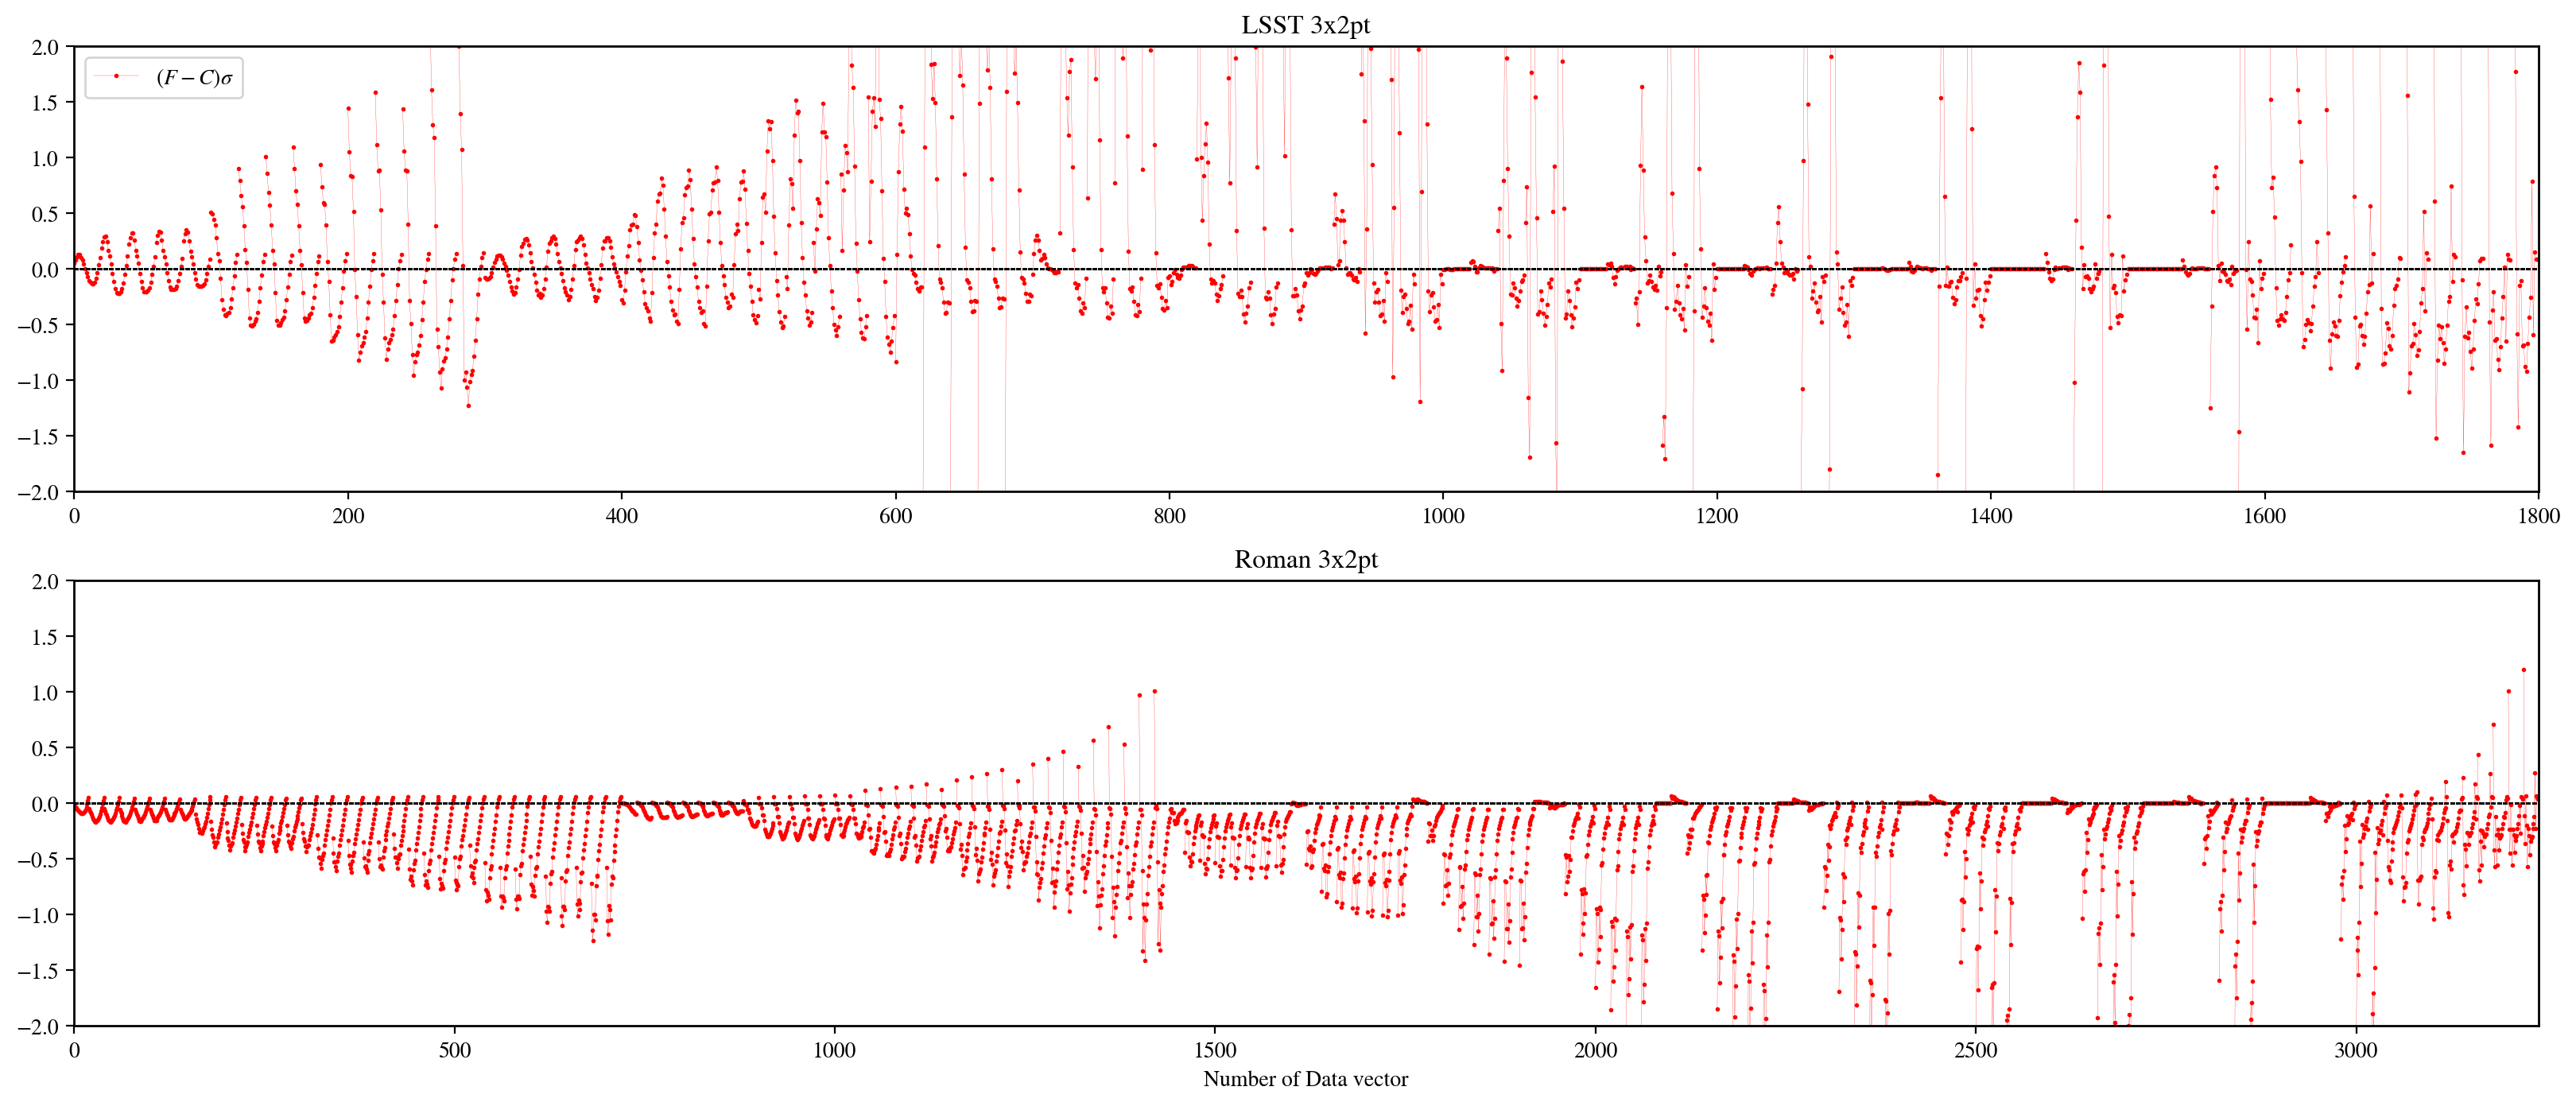

In [2]:
import matplotlib.pyplot as plt

#load LSST data
import numpy as np

nlens = 10
nsrcs = 5
ntheta=20
tmin = 1
tmax = 500

dvF_file = '/project/chihway/junzhou/firecrown/lsst_real/output_factory/data_vector/firecrown_theory.txt'
dvC_file = '/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/chains/lsst_limber+noRSD+takahashi_evaluate/lsst_limber+noRSD+takahashi.modelvector'
cov_file = '/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/data/cov_lsst'
mask_file = '/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/data/lsst_Y3.mask'

dvF = np.loadtxt(dvF_file)
dvC = np.loadtxt(dvC_file)[:,1]
mask = np.loadtxt(mask_file)[:,1]

cov_raw = np.loadtxt(cov_file)
cov = np.zeros((len(mask),len(mask)))
for idx in range(len(cov_raw)):
    ii = int(cov_raw[idx,0])
    jj = int(cov_raw[idx,1])
    element = cov_raw[idx,8] + cov_raw[idx,9]
    cov[ii,jj] = element
    cov[jj,ii] = element

#chi2 after mask
from scipy.linalg import pinv
delta = dvF - dvC
masked_delta = delta[mask.astype(bool)]
masked_cov = cov[mask.astype(bool), :][:, mask.astype(bool)]
chi2 = masked_delta@pinv(masked_cov)@masked_delta
print('total chi2 after mask:', chi2)

#define plot function
def plot_assemble(axs, cnt, probe, combo):
    l,r = int(cnt*ntheta), int(cnt+1)*ntheta
    thetas = np.arange(int(cnt)*20, int(cnt+1)*20)
    cov_seg = cov[l:r,:][:,l:r]
    sigmas = np.array([np.sqrt(cov_seg[i,i]) for i in range(len(cov_seg))])
    delta = (dvF[l:r] - dvC[l:r])/sigmas
    axs.plot(thetas, delta, marker='o',color='r',markersize=1,linewidth=0.1)
    #axs.fill_between(thetas,-sigmas/dvC[l:r],+sigmas/dvC[l:r],step='mid',facecolor='lightgray',alpha=0.5)
    axs.axhline(xmin=0,xmax=1,y=0.0,color='k',linestyle='--',linewidth=0.5)
    axs.set_ylim(-2, 2)

#assemble
fig,ax = plt.subplots(2,1,figsize=(20,8))
cnt = 0

#initiate legends
l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
plot_assemble(ax[0], cnt, probe=r'$\xi^+$', combo=f'{0}x{0}')
cnt+=1
ax[0].legend([r'$(F-C)\sigma$'])

#start loop
for i in range(nsrcs):
    for j in range(i, nsrcs):
        if(i==0 and j==0):
            continue
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        plot_assemble(ax[0], cnt, probe=r'$\xi^+$', combo=f'{i}x{j}')
        cnt+=1
for i in range(nsrcs):
    for j in range(i, nsrcs):
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        plot_assemble(ax[0], cnt, probe=r'$\xi^-$', combo=f'{i}x{j}')
        cnt+=1
for i in range(nlens):
    for j in range(nsrcs):
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        plot_assemble(ax[0], cnt, probe=r'$\gamma t$', combo=f'{i}x{j}')
        cnt+=1
for i in range(nlens):
    l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
    plot_assemble(ax[0], cnt, probe=r'$W(\theta)$', combo=f'{i}x{i}')
    cnt+=1
    
#general settings for plot
ax[0].set_title('LSST 3x2pt')
ax[0].set_xlabel('')
ax[0].set_ylim(-2, 2)
ax[0].set_xlim(0, cnt*ntheta)

#load Roman data
import numpy as np

nlens = 10
nsrcs = 8
ntheta=20
tmin = 1
tmax = 500

dvF_file = '/project/chihway/junzhou/firecrown/roman_real/output_factory/data_vector/firecrown_theory.txt'
dvC_file = '/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_limber+noRSD+takahashi_evaluate/roman_limber+noRSD+takahashi.modelvector'
cov_file = '/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/cov_roman'
mask_file = '/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/roman_Y3.mask'

dvF = np.loadtxt(dvF_file)
dvC = np.loadtxt(dvC_file)[:,1]
mask = np.loadtxt(mask_file)[:,1]

cov_raw = np.loadtxt(cov_file)
cov = np.zeros((len(mask),len(mask)))
for idx in range(len(cov_raw)):
    ii = int(cov_raw[idx,0])
    jj = int(cov_raw[idx,1])
    element = cov_raw[idx,8] + cov_raw[idx,9]
    cov[ii,jj] = element
    cov[jj,ii] = element

delta = dvF - dvC
masked_delta = delta[mask.astype(bool)]
masked_cov = cov[mask.astype(bool), :][:, mask.astype(bool)]
chi2 = masked_delta@pinv(masked_cov)@masked_delta
print('total chi2 after mask:', chi2)

#restart whole process
cnt = 0
#start loop
for i in range(nsrcs):
    for j in range(i, nsrcs):
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        plot_assemble(ax[1], cnt, probe=r'$\xi^+$', combo=f'{i}x{j}')
        cnt+=1
for i in range(nsrcs):
    for j in range(i, nsrcs):
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        plot_assemble(ax[1], cnt, probe=r'$\xi^-$', combo=f'{i}x{j}')
        cnt+=1
for i in range(nlens):
    for j in range(nsrcs):
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        plot_assemble(ax[1], cnt, probe=r'$\gamma t$', combo=f'{i}x{j}')
        cnt+=1
for i in range(nlens):
    l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
    plot_assemble(ax[1], cnt, probe=r'$W(\theta)$', combo=f'{i}x{i}')
    cnt+=1
    
#general settings for plot
ax[1].set_xlabel('Number of Data vector')
ax[1].set_title('Roman 3x2pt')
ax[1].set_ylim(-2, 2)
ax[1].set_xlim(0, cnt*ntheta)

plt.show()


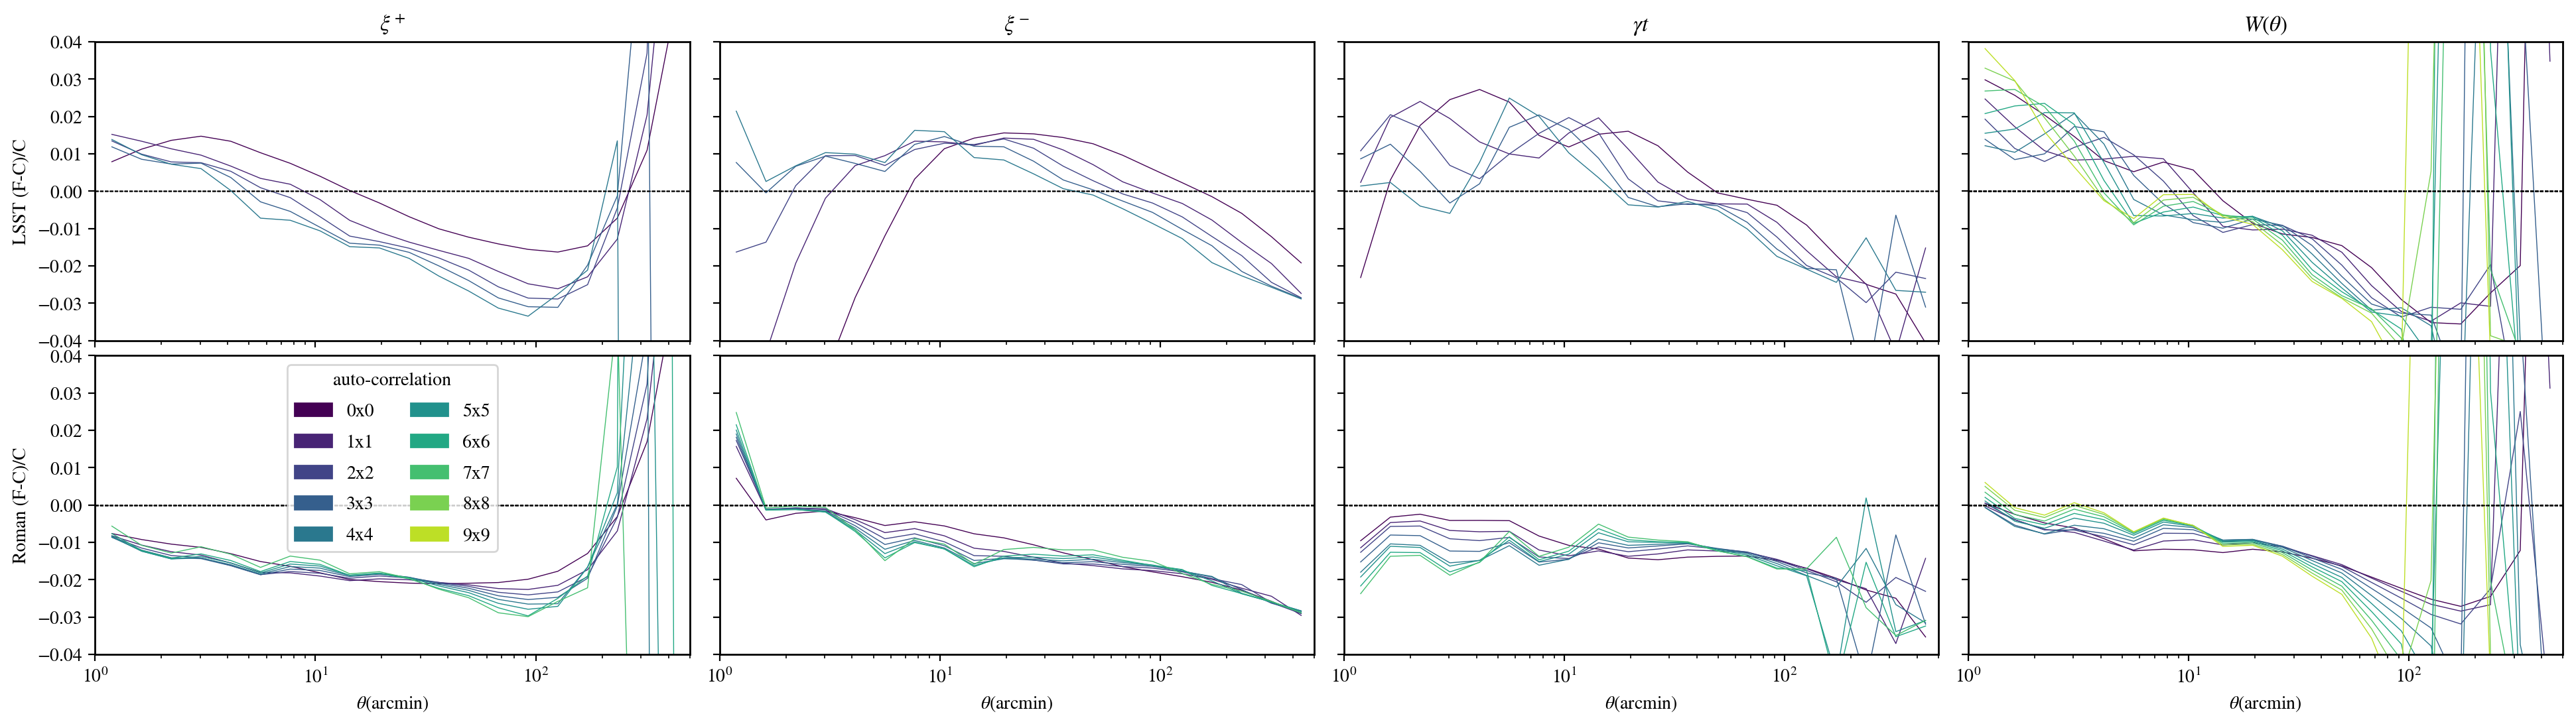

In [ ]:
import matplotlib.pyplot as plt

#thetas used in COCOA
vmin = tmin
vmax = tmax
N = ntheta
logdt = (np.log(vmax) - np.log(vmin))/N
fac = (2./3.)
thetas = []
for i in range(int(N)):
    thetamin = np.exp(np.log(vmin) + (i + 0.)*logdt)
    thetamax = np.exp(np.log(vmin) + (i + 1.)*logdt)
    thetas.append(fac * (thetamax**3 - thetamin**3) / (thetamax**2 - thetamin**2))
thetas = np.array(thetas)

#load LSST data
import numpy as np

nlens = 10
nsrcs = 5
ntheta=20
tmin = 1
tmax = 500

dvF_file = '/project/chihway/junzhou/firecrown/lsst_real/output_factory/data_vector/firecrown_theory.txt'
dvC_file = '/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/chains/lsst_limber+noRSD+takahashi_evaluate/lsst_limber+noRSD+takahashi.modelvector'
mask_file = '/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/data/lsst_Y3.mask'

dvF = np.loadtxt(dvF_file)
dvC = np.loadtxt(dvC_file)[:,1]
mask = np.loadtxt(mask_file)[:,1]

#define plot function
def plot_assemble(axs, cnt, probe, combo, color):
    l,r = int(cnt*ntheta), int(cnt+1)*ntheta
    delta = (dvF[l:r] - dvC[l:r])
    axs.plot(thetas, delta/dvC[l:r],markersize=1,linewidth=0.5,label=combo,color=color)
    #axs.fill_between(thetas,-sigmas/dvC[l:r],+sigmas/dvC[l:r],step='mid',facecolor='lightgray',alpha=0.5)
    axs.axhline(xmin=0,xmax=1,y=0.0,color='k',linestyle='--',linewidth=0.5)
    #axs.set_ylim(-2, 2)
    axs.set_xscale('log')

import matplotlib.patches as mpatches

#assemble
fig,ax = plt.subplots(2,4,figsize=(24,6))
plt.subplots_adjust(hspace=0.05)
plt.subplots_adjust(wspace=0.05)
cmap = plt.get_cmap("viridis")
colors = cmap(np.arange(0, nlens)/nlens)
patches = [
    mpatches.Patch(color=colors[i], label=f"{i}x{i}")
    for i in range(nlens)
]

cnt = 0
ax[0,0].set_ylabel('LSST (F-C)/C')
ax[0,0].set_title(r'$\xi^+$')
ax[0,1].set_title(r'$\xi^-$')
ax[0,2].set_title(r'$\gamma t$')
ax[0,3].set_title(r'$W(\theta)$')
ax[0,0].tick_params(axis='x', labelbottom=False)
ax[0,1].tick_params(axis='x', labelbottom=False)
ax[0,2].tick_params(axis='x', labelbottom=False)
ax[0,3].tick_params(axis='x', labelbottom=False)
ax[0,1].tick_params(axis='y', labelleft=False)
ax[0,2].tick_params(axis='y', labelleft=False)
ax[0,3].tick_params(axis='y', labelleft=False)
ax[0,0].set_xlim(1,500)
ax[0,1].set_xlim(1,500)
ax[0,2].set_xlim(1,500)
ax[0,3].set_xlim(1,500)
ax[0,0].set_ylim(-0.04,0.04)
ax[0,1].set_ylim(-0.04,0.04)
ax[0,2].set_ylim(-0.04,0.04)
ax[0,3].set_ylim(-0.04,0.04)

#start loop
for i in range(nsrcs):
    for j in range(i, nsrcs):
        if i!=j:
            cnt+=1
            continue
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        plot_assemble(ax[0,0], cnt, probe=r'$\xi^+$', combo=f'{i}x{j}',color=cmap(i/nlens))
        cnt+=1
for i in range(nsrcs):
    for j in range(i, nsrcs):
        if i!=j:
            cnt+=1
            continue
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        plot_assemble(ax[0,1], cnt, probe=r'$\xi^-$', combo=f'{i}x{j}',color=cmap(i/nlens))
        cnt+=1
for i in range(nlens):
    for j in range(nsrcs):
        if i!=j:
            cnt+=1
            continue
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        plot_assemble(ax[0,2], cnt, probe=r'$\gamma t$', combo=f'{i}x{j}',color=cmap(i/nlens))
        cnt+=1
for i in range(nlens):
    l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
    plot_assemble(ax[0,3], cnt, probe=r'$W(\theta)$', combo=f'{i}x{i}',color=cmap(i/nlens))
    cnt+=1

nlens = 10
nsrcs = 8
ntheta=20
tmin = 1
tmax = 500

dvF_file = '/project/chihway/junzhou/firecrown/roman_real/output_factory/data_vector/firecrown_theory.txt'
dvC_file = '/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_limber+noRSD+takahashi_evaluate/roman_limber+noRSD+takahashi.modelvector'
mask_file = '/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/roman_Y3.mask'

dvF = np.loadtxt(dvF_file)
dvC = np.loadtxt(dvC_file)[:,1]
mask = np.loadtxt(mask_file)[:,1]

cnt = 0
ax[1,0].set_ylabel('Roman (F-C)/C')
ax[1,0].set_xlabel(r'$\theta(\mathrm{arcmin})$')
ax[1,1].set_xlabel(r'$\theta(\mathrm{arcmin})$')
ax[1,2].set_xlabel(r'$\theta(\mathrm{arcmin})$')
ax[1,3].set_xlabel(r'$\theta(\mathrm{arcmin})$')
ax[1,1].tick_params(axis='y', labelleft=False)
ax[1,2].tick_params(axis='y', labelleft=False)
ax[1,3].tick_params(axis='y', labelleft=False)
ax[1,0].set_xlim(1,500)
ax[1,1].set_xlim(1,500)
ax[1,2].set_xlim(1,500)
ax[1,3].set_xlim(1,500)
ax[1,0].set_ylim(-0.04,0.04)
ax[1,1].set_ylim(-0.04,0.04)
ax[1,2].set_ylim(-0.04,0.04)
ax[1,3].set_ylim(-0.04,0.04)

#start loop
for i in range(nsrcs):
    for j in range(i, nsrcs):
        if i!=j:
            cnt+=1
            continue
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        plot_assemble(ax[1,0], cnt, probe=r'$\xi^+$', combo=f'{i}x{j}',color=cmap(i/nlens))
        cnt+=1
for i in range(nsrcs):
    for j in range(i, nsrcs):
        if i!=j:
            cnt+=1
            continue
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        plot_assemble(ax[1,1], cnt, probe=r'$\xi^-$', combo=f'{i}x{j}',color=cmap(i/nlens))
        cnt+=1
for i in range(nlens):
    for j in range(nsrcs):
        if i!=j:
            cnt+=1
            continue
        l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
        plot_assemble(ax[1,2], cnt, probe=r'$\gamma t$', combo=f'{i}x{j}',color=cmap(i/nlens))
        cnt+=1
for i in range(nlens):
    l,r = int(cnt*ntheta),int((cnt+1)*ntheta)
    plot_assemble(ax[1,3], cnt, probe=r'$W(\theta)$', combo=f'{i}x{i}',color=cmap(i/nlens))
    cnt+=1

ax[1,0].legend(handles=patches, title="auto-correlation", ncol=2)